<a href="https://colab.research.google.com/github/madaam99/EnergyGermany/blob/main/Modelling/Modelling_SMARD_Capacity_Germany_Monthly.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install utilsforecast statsforecast mlforecast neuralforecast

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.2/263.2 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.4/287.4 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.7/280.7 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.5/849.5 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.3/72.3 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.2/102.2 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
from google.colab import files

In [3]:
upload = files.upload()

Saving processedInstalledEnergy to processedInstalledEnergy


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *

from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, SeasonalNaive

from mlforecast import MLForecast
from mlforecast.target_transforms import LocalStandardScaler
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS, TFT

import warnings
warnings.filterwarnings('ignore')

In [5]:
capacity = pd.read_csv("processedInstalledEnergy")

capacity.tail()

,Datum von,Datum bis,Gesamtkapazität [MWh],Biomasse [MWh],Wasserkraft [MWh],Wind Offshore [MWh],Wind Onshore [MWh],Photovoltaik [MWh],Sonstige Erneuerbare [MWh],Kernenergie [MWh],Braunkohle [MWh],Steinkohle [MWh],Erdgas [MWh],Pumpspeicher [MWh],Sonstige Konventionelle [MWh]
55,2025-08-01,2025-09-01,196023912.0,6521904.0,3980400.0,6855960.0,47014848.0,64287552.0,331824.0,0.0,11290944.0,11867544.0,27240816.0,6981696.0,9650424.0
56,2025-09-01,2025-10-01,189700560.0,6311520.0,3852000.0,6634800.0,45498240.0,62213760.0,321120.0,0.0,10926720.0,11484720.0,26362080.0,6756480.0,9339120.0
57,2025-10-01,2025-11-01,196023912.0,6521904.0,3980400.0,6855960.0,47014848.0,64287552.0,331824.0,0.0,11290944.0,11867544.0,27240816.0,6981696.0,9650424.0
58,2025-11-01,2025-12-01,189700560.0,6311520.0,3852000.0,6634800.0,45498240.0,62213760.0,321120.0,0.0,10926720.0,11484720.0,26362080.0,6756480.0,9339120.0
59,2025-12-01,2026-01-01,196023912.0,6521904.0,3980400.0,6855960.0,47014848.0,64287552.0,331824.0,0.0,11290944.0,11867544.0,27240816.0,6981696.0,9650424.0


In [6]:
capacity['Datum von'] = pd.to_datetime(capacity['Datum von'])
capacity['Datum bis'] = pd.to_datetime(capacity['Datum bis'])

##Modelling with Capacity as Focus

Melting DFs and renaming to fit statsforecast, mlforecast, and neuralforecast better

In [7]:
capacity_melted = capacity.drop(columns="Datum bis").melt(id_vars=['Datum von'], var_name='unique_id', value_name='y')

capacity_melted.rename(columns={'Datum von': 'ds'}, inplace=True)

capacity_melted.head()

,ds,unique_id,y
0,2021-01-01,Gesamtkapazität [MWh],107806344.0
1,2021-02-01,Gesamtkapazität [MWh],97373472.0
2,2021-03-01,Gesamtkapazität [MWh],107806344.0
3,2021-04-01,Gesamtkapazität [MWh],104328720.0
4,2021-05-01,Gesamtkapazität [MWh],107806344.0


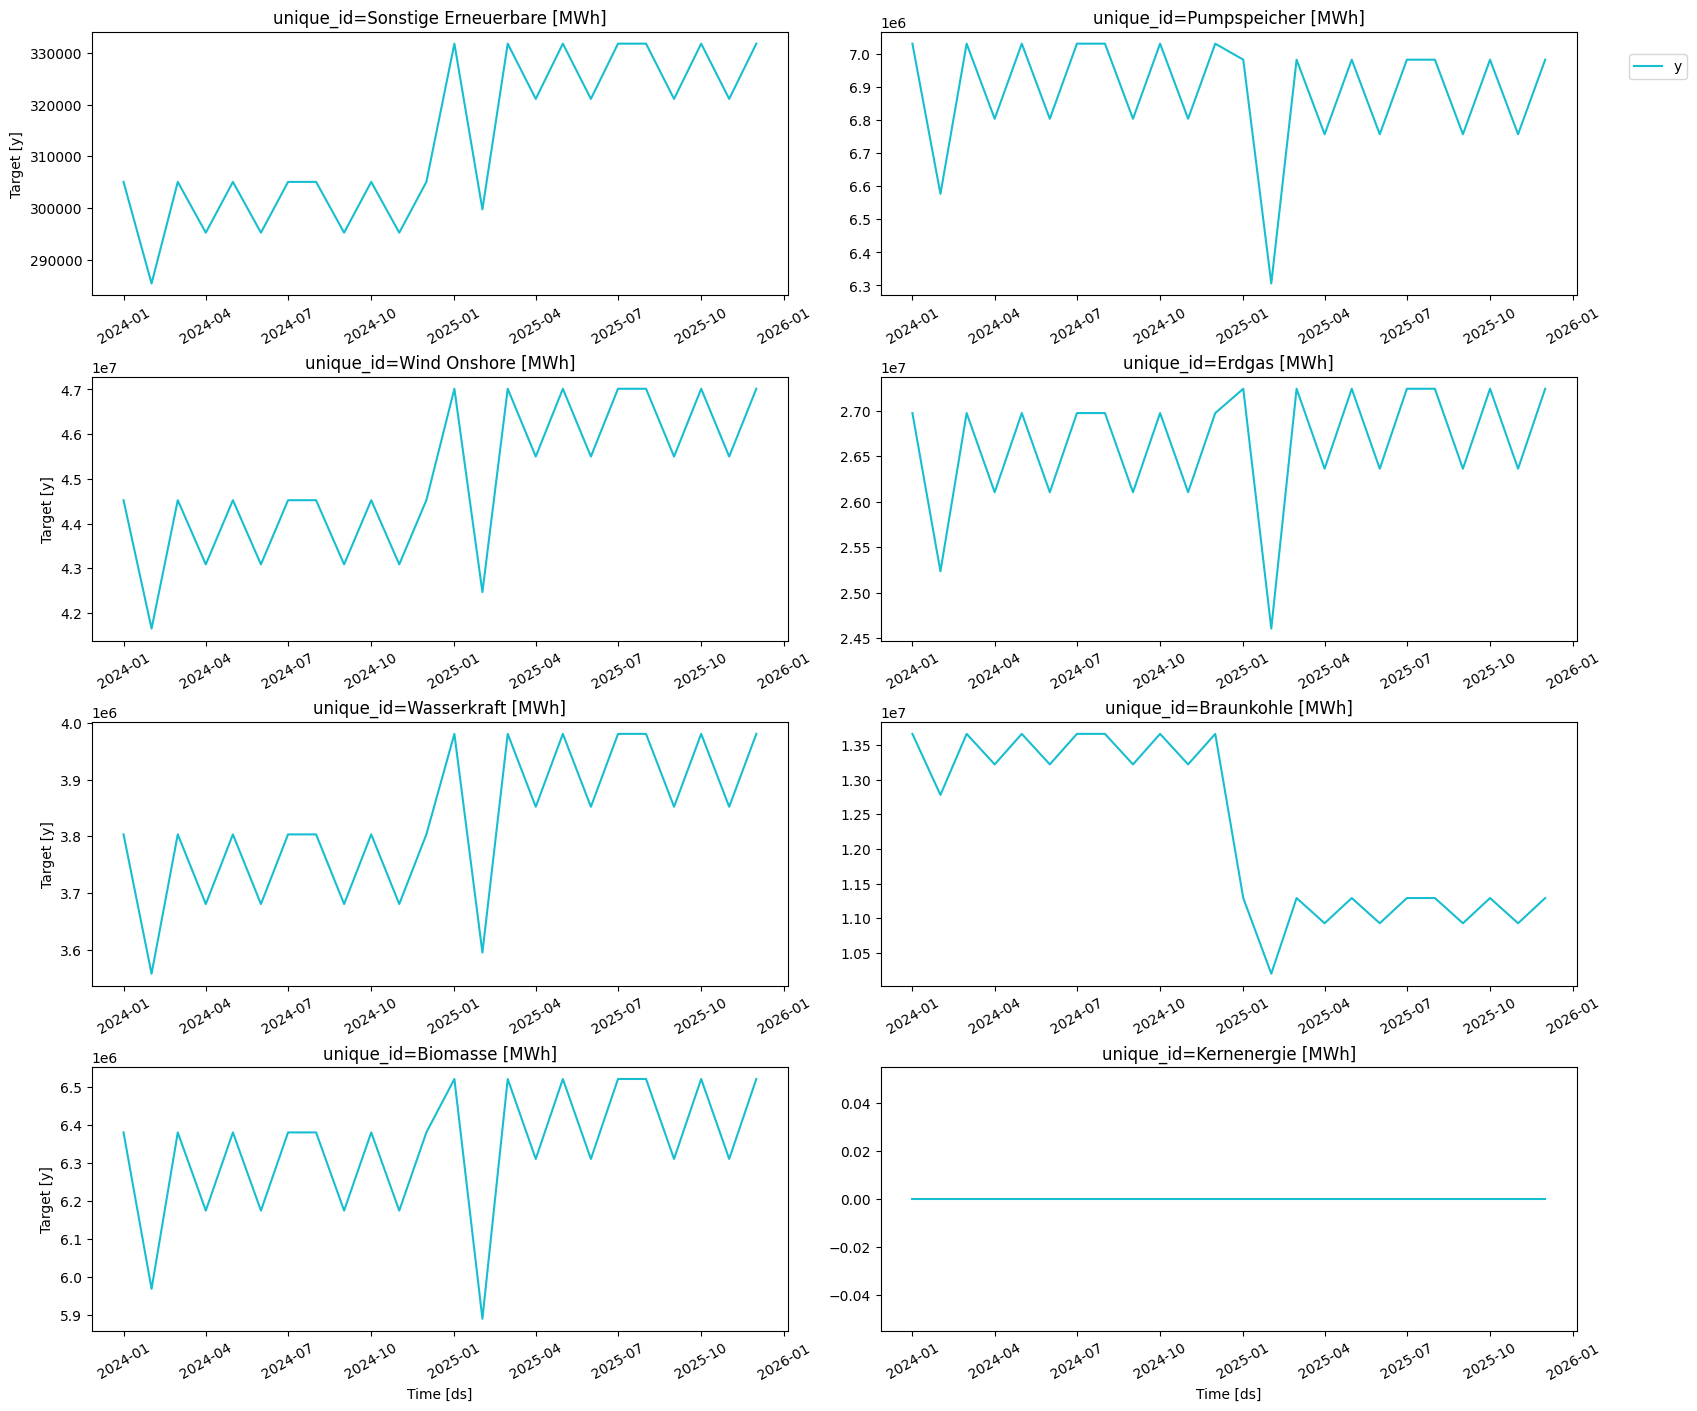

In [8]:
plot_series(df=capacity_melted, max_insample_length=24)

In [9]:
testCapacityStat = capacity_melted.groupby('unique_id').tail(3)
trainCapacityStat = capacity_melted.drop(testCapacityStat.index)

###Statsforecast

In [10]:
models = [
    AutoARIMA(alias="ARIMA"),
    AutoARIMA(season_length=12, alias="SARIMA"),
    SeasonalNaive(season_length=12)
]

sf = StatsForecast(models=models, freq='MS')
sf.fit(trainCapacityStat)
predStatCap = sf.predict(3)

predStatCap.head()

,unique_id,ds,ARIMA,SARIMA,SeasonalNaive
0,Biomasse [MWh],2025-10-01,6.491792e+06,6.496005e+06,6381288.0
1,Biomasse [MWh],2025-11-01,6.427792e+06,6.292265e+06,6175440.0
2,Biomasse [MWh],2025-12-01,6.445782e+06,6.496005e+06,6381288.0
3,Braunkohle [MWh],2025-10-01,1.092672e+07,1.092672e+07,13662072.0
4,Braunkohle [MWh],2025-11-01,1.092672e+07,1.092672e+07,13221360.0


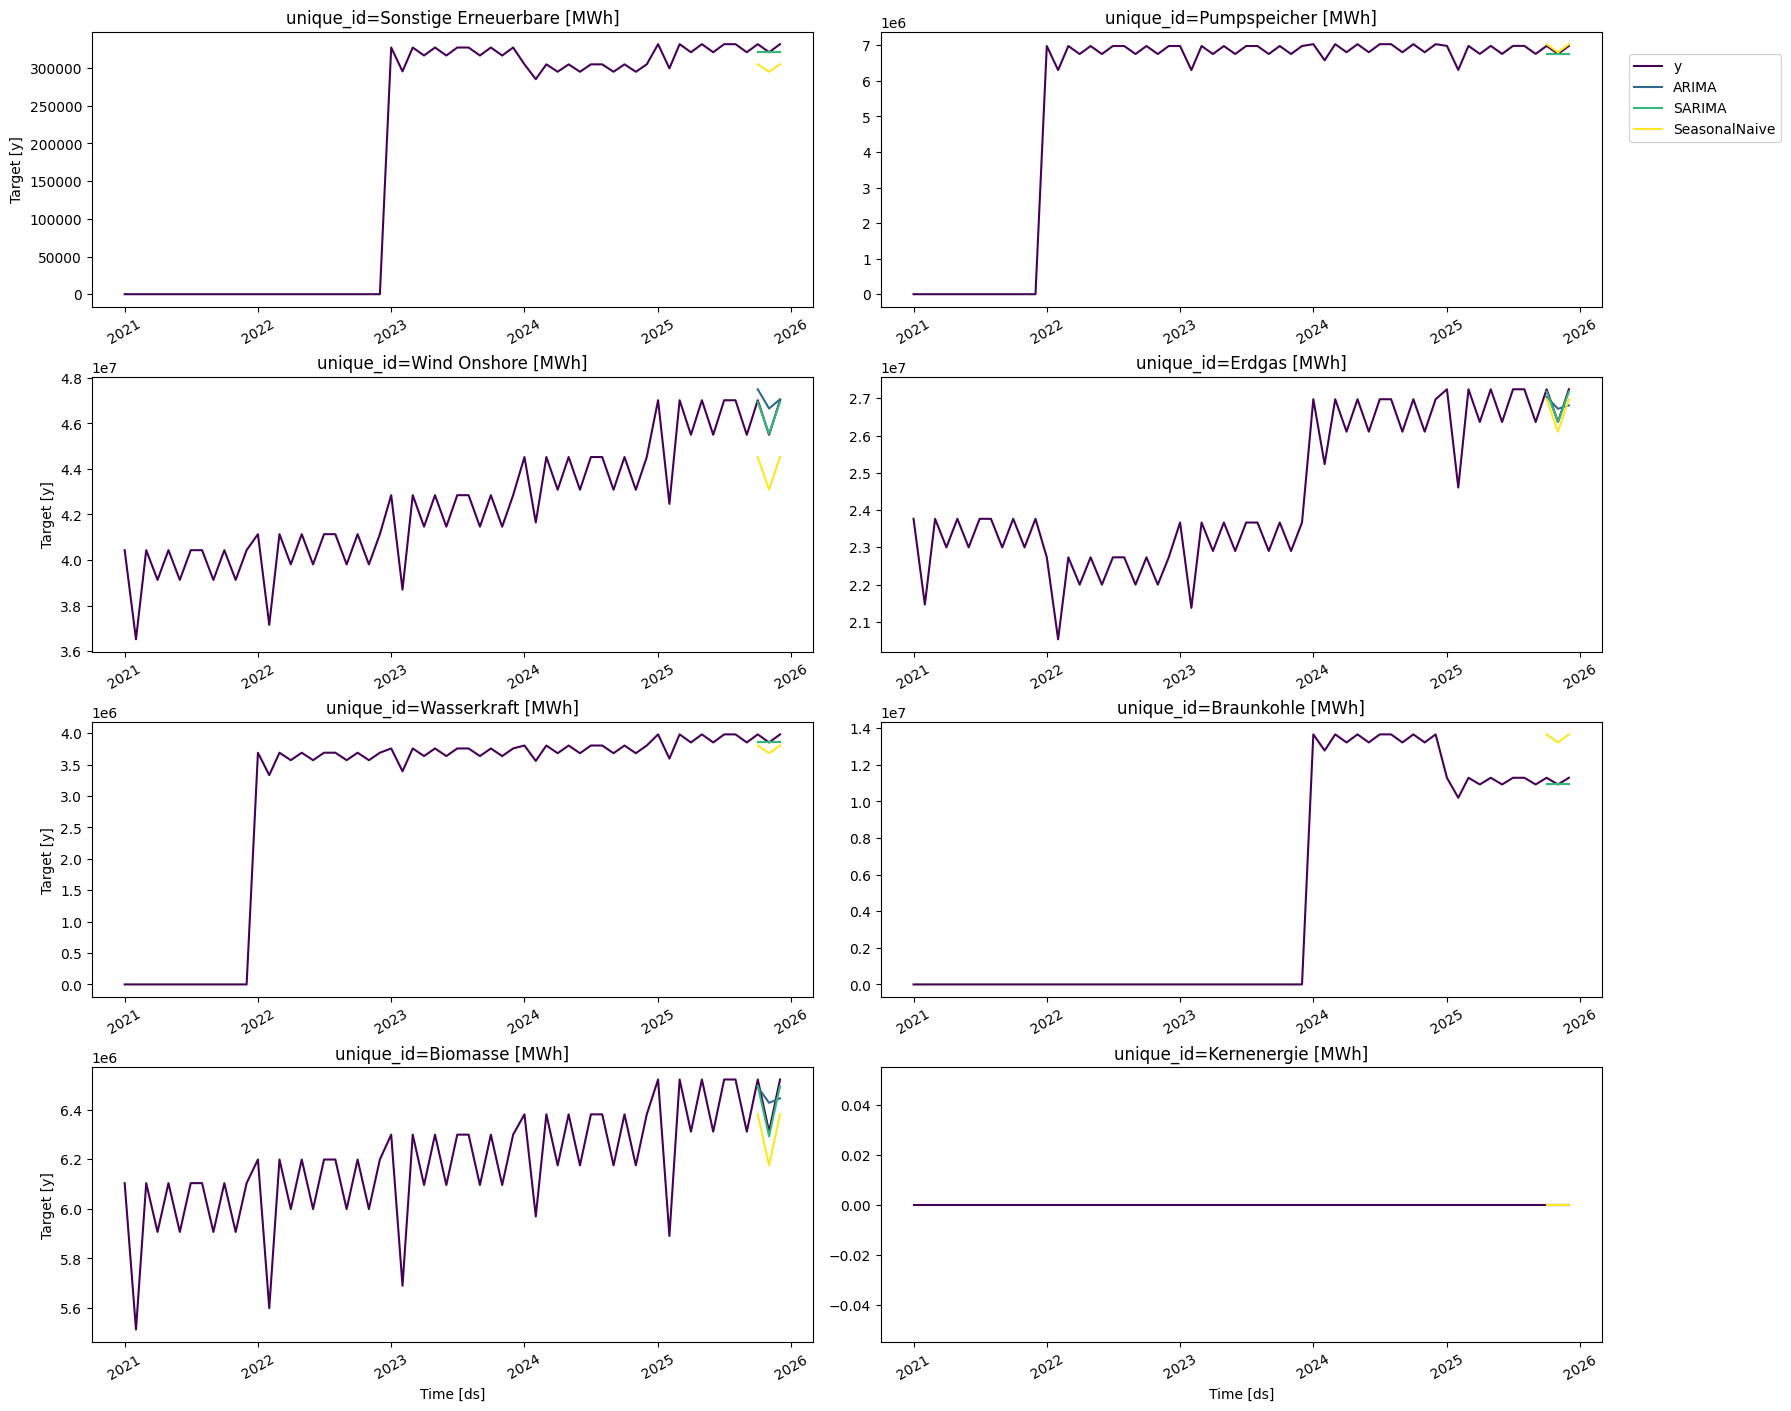

In [11]:
plot_series(df=capacity_melted, forecasts_df=predStatCap, palette="viridis")

In [12]:
eval_df = pd.merge(testCapacityStat, predStatCap, "left", ["ds", "unique_id"])
evaluation = evaluate(eval_df, metrics=[mae])
evaluation.head()

,unique_id,metric,ARIMA,SARIMA,SeasonalNaive
0,Biomasse [MWh],mae,7.416858e+04,23684.133372,139104.0
1,Braunkohle [MWh],mae,2.428160e+05,242816.000000,2345632.0
2,Erdgas [MWh],mae,3.306748e+05,43328.264591,264224.0
3,Gesamtkapazität [MWh],mae,2.234178e+06,908630.848446,9704160.0
4,Kernenergie [MWh],mae,0.000000e+00,0.000000,0.0


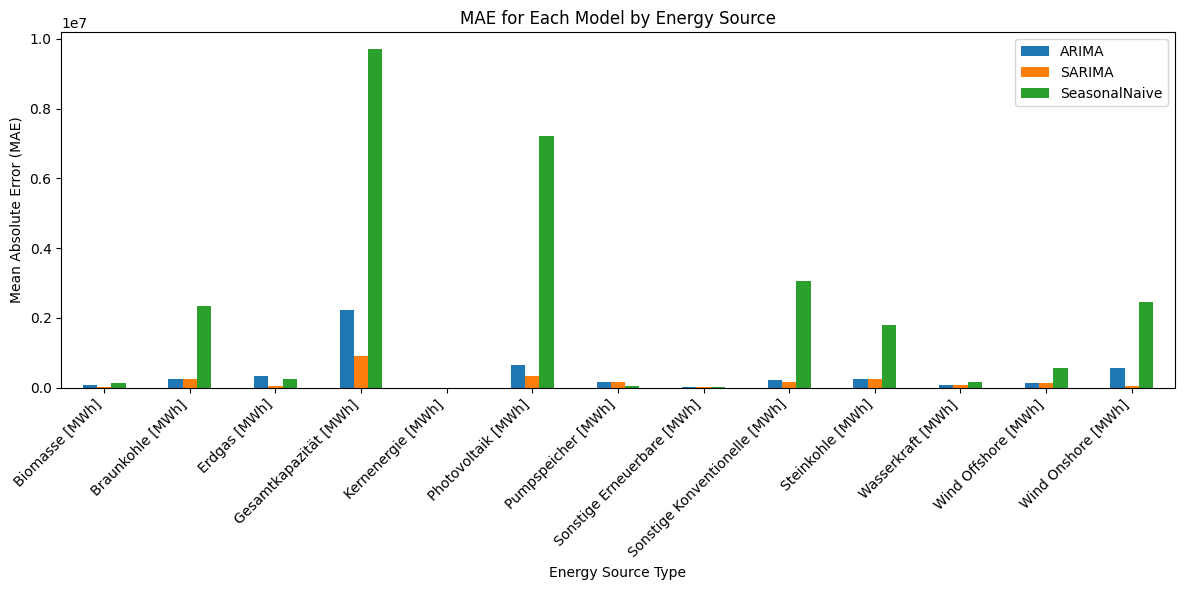

In [13]:
evaluation_for_plot = evaluation.set_index('unique_id')
evaluation_for_plot = evaluation_for_plot.drop(columns='metric')

evaluation_for_plot.plot(kind="bar", figsize=(12, 6))
plt.ylabel("Mean Absolute Error (MAE)")
plt.xlabel("Energy Source Type")
plt.title("MAE for Each Model by Energy Source")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Cross-Validation

In [14]:
models = [
    AutoARIMA(alias="ARIMA"),
    AutoARIMA(season_length=12, alias="SARIMA"),
    SeasonalNaive(season_length=12)
]

sf = StatsForecast(models=models, freq='MS')
cv = sf.cross_validation(
    df=trainCapacityStat,
    h=3,
    step_size=3,
    n_windows=4,
    refit=True,
)

cv.head()

,unique_id,ds,cutoff,y,ARIMA,SARIMA,SeasonalNaive
0,Biomasse [MWh],2024-10-01,2024-09-01,6381288.0,6.345017e+06,6.397340e+06,6299448.0
1,Biomasse [MWh],2024-11-01,2024-09-01,6175440.0,6.316206e+06,6.194132e+06,6096240.0
2,Biomasse [MWh],2024-12-01,2024-09-01,6381288.0,6.322981e+06,6.397340e+06,6299448.0
3,Biomasse [MWh],2025-01-01,2024-12-01,6521904.0,6.311144e+06,6.477769e+06,6381288.0
4,Biomasse [MWh],2025-02-01,2024-12-01,5890752.0,6.325117e+06,6.066073e+06,5969592.0


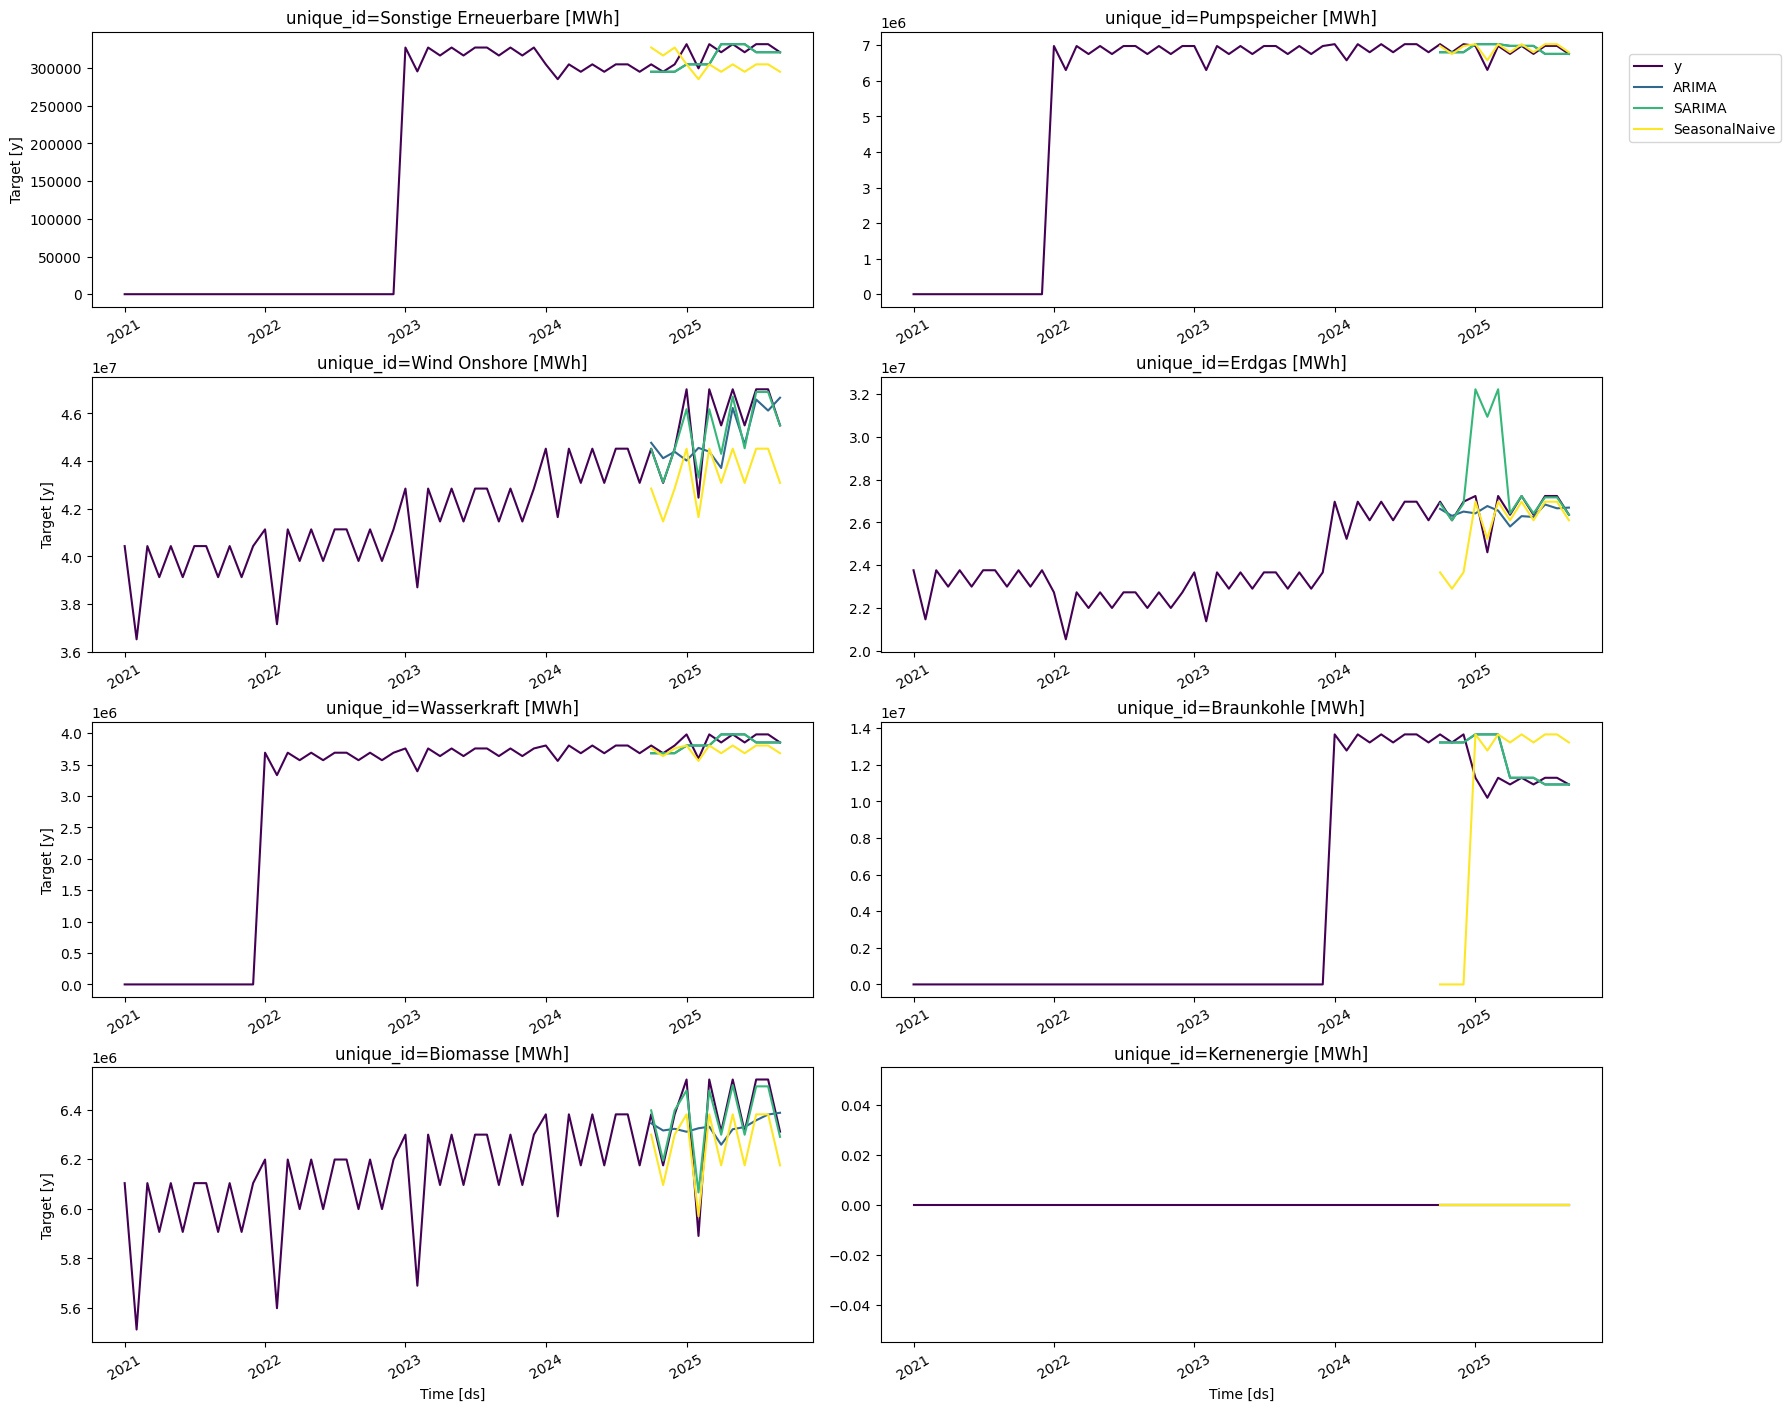

In [15]:
plot_series(df=trainCapacityStat, forecasts_df=cv.drop(columns=["y", "cutoff"]), palette="viridis")

In [16]:
cv_eval = evaluate(cv.drop(columns="cutoff"), metrics=[mae])

cv_eval = cv_eval.drop(columns=["unique_id"]).groupby("metric").mean().reset_index()
cv_eval

,metric,ARIMA,SARIMA,SeasonalNaive
0,mae,868177.841368,1.172852e+06,3121920.0


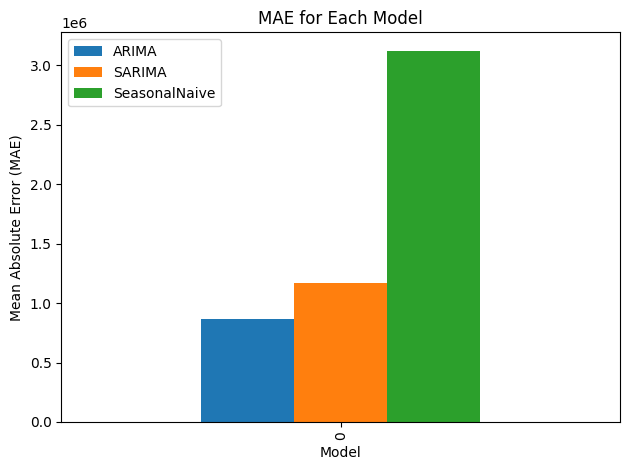

In [17]:
cv_eval.plot(kind="bar")
plt.ylabel("Mean Absolute Error (MAE)")
plt.xlabel("Model")
plt.title("MAE for Each Model")
plt.tight_layout()
plt.show()

###MLForecast

In [18]:
testCapacity = capacity.tail(3)
trainCapacity = capacity.drop(testCapacity.index)

In [19]:
trainCapacity = trainCapacity.drop(columns="Datum bis").melt(id_vars=['Datum von'], var_name='unique_id', value_name='y')
testCapacity = testCapacity.drop(columns="Datum bis").melt(id_vars=['Datum von'], var_name='unique_id', value_name='y')

trainCapacity.rename(columns={'Datum von': 'ds'}, inplace=True)
testCapacity.rename(columns={'Datum von': 'ds'}, inplace=True)

display(trainCapacity.tail())
display(testCapacity.tail())

,ds,unique_id,y
736,2025-05-01,Sonstige Konventionelle [MWh],9650424.0
737,2025-06-01,Sonstige Konventionelle [MWh],9339120.0
738,2025-07-01,Sonstige Konventionelle [MWh],9650424.0
739,2025-08-01,Sonstige Konventionelle [MWh],9650424.0
740,2025-09-01,Sonstige Konventionelle [MWh],9339120.0


,ds,unique_id,y
34,2025-11-01,Pumpspeicher [MWh],6756480.0
35,2025-12-01,Pumpspeicher [MWh],6981696.0
36,2025-10-01,Sonstige Konventionelle [MWh],9650424.0
37,2025-11-01,Sonstige Konventionelle [MWh],9339120.0
38,2025-12-01,Sonstige Konventionelle [MWh],9650424.0


In [20]:
models = [
    LinearRegression(),
    XGBRegressor(),
    LGBMRegressor()
]

mlf = MLForecast(models=models, freq='MS', lags=list(range(1, 12)), target_transforms=[LocalStandardScaler()])

mlf.fit(trainCapacity)
predMlCap = mlf.predict(3)

predMlCap.head()

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001130 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 911
[LightGBM] [Info] Number of data points in the train set: 598, number of used features: 11
[LightGBM] [Info] Start training from score 0.246023
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

,unique_id,ds,LinearRegression,XGBRegressor,LGBMRegressor
0,Biomasse [MWh],2025-10-01,6.525689e+06,6.542568e+06,6.530375e+06
1,Biomasse [MWh],2025-11-01,6.356849e+06,6.353697e+06,6.335052e+06
2,Biomasse [MWh],2025-12-01,6.357352e+06,6.555617e+06,6.491229e+06
3,Braunkohle [MWh],2025-10-01,1.077761e+07,1.179279e+07,1.120674e+07
4,Braunkohle [MWh],2025-11-01,9.922610e+06,1.174426e+07,1.101123e+07


In [21]:
eval_df = pd.merge(testCapacity, predMlCap, "left", ["ds", "unique_id"])
evaluation = evaluate(eval_df, metrics=[mae])
evaluation.head()

,unique_id,metric,LinearRegression,XGBRegressor,LGBMRegressor
0,Biomasse [MWh],mae,7.122210e+04,3.218428e+04,2.089291e+04
1,Braunkohle [MWh],mae,8.837920e+05,8.089507e+05,2.390630e+05
2,Erdgas [MWh],mae,3.428710e+05,3.535491e+05,2.708902e+05
3,Gesamtkapazität [MWh],mae,3.399070e+06,1.438454e+06,4.169343e+06
4,Kernenergie [MWh],mae,1.053664e-01,1.622039e-04,1.152849e-02


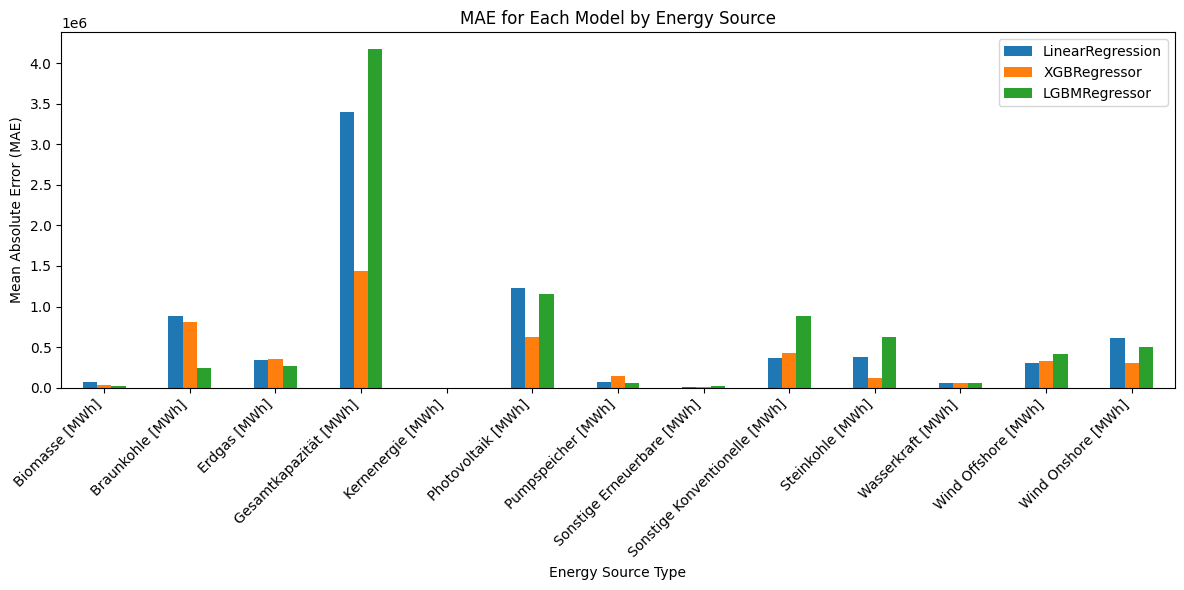

In [22]:
evaluation_to_plot = evaluation.drop(columns="metric").set_index("unique_id")

evaluation_to_plot.plot(kind="bar", figsize=(12, 6))
plt.ylabel("Mean Absolute Error (MAE)")
plt.xlabel("Energy Source Type")
plt.title("MAE for Each Model by Energy Source")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

ML Cross-Validation

In [23]:
models = [
    LinearRegression(),
    XGBRegressor(),
    LGBMRegressor()
]

mlf = MLForecast(models=models, freq="MS", lags=list(range(1, 13)), target_transforms=[LocalStandardScaler()])

cv_ml = mlf.cross_validation(df=trainCapacity, n_windows=4, h=3)

cv_ml

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000037 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 656
[LightGBM] [Info] Number of data points in the train set: 429, number of used features: 12
[LightGBM] [Info] Start training from score 0.297435
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

,unique_id,ds,cutoff,y,LinearRegression,XGBRegressor,LGBMRegressor
0,Biomasse [MWh],2024-10-01,2024-09-01,6381288.0,6.393604e+06,6.402963e+06,6.413100e+06
1,Biomasse [MWh],2024-11-01,2024-09-01,6175440.0,6.169462e+06,6.265865e+06,6.251291e+06
2,Biomasse [MWh],2024-12-01,2024-09-01,6381288.0,6.295780e+06,6.403431e+06,6.398421e+06
3,Braunkohle [MWh],2024-10-01,2024-09-01,13662072.0,1.329736e+07,1.302421e+07,1.257164e+07
4,Braunkohle [MWh],2024-11-01,2024-09-01,13221360.0,1.097903e+07,1.302058e+07,1.250827e+07
...,...,...,...,...,...,...,...
151,Wind Offshore [MWh],2025-08-01,2025-06-01,6855960.0,6.953881e+06,6.448948e+06,6.060327e+06
152,Wind Offshore [MWh],2025-09-01,2025-06-01,6634800.0,6.802675e+06,6.378876e+06,5.873179e+06
153,Wind Onshore [MWh],2025-07-01,2025-06-01,47014848.0,4.601480e+07,4.508310e+07,4.583806e+07
154,Wind Onshore [MWh],2025-08-01,2025-06-01,47014848.0,4.695298e+07,4.602972e+07,4.579959e+07


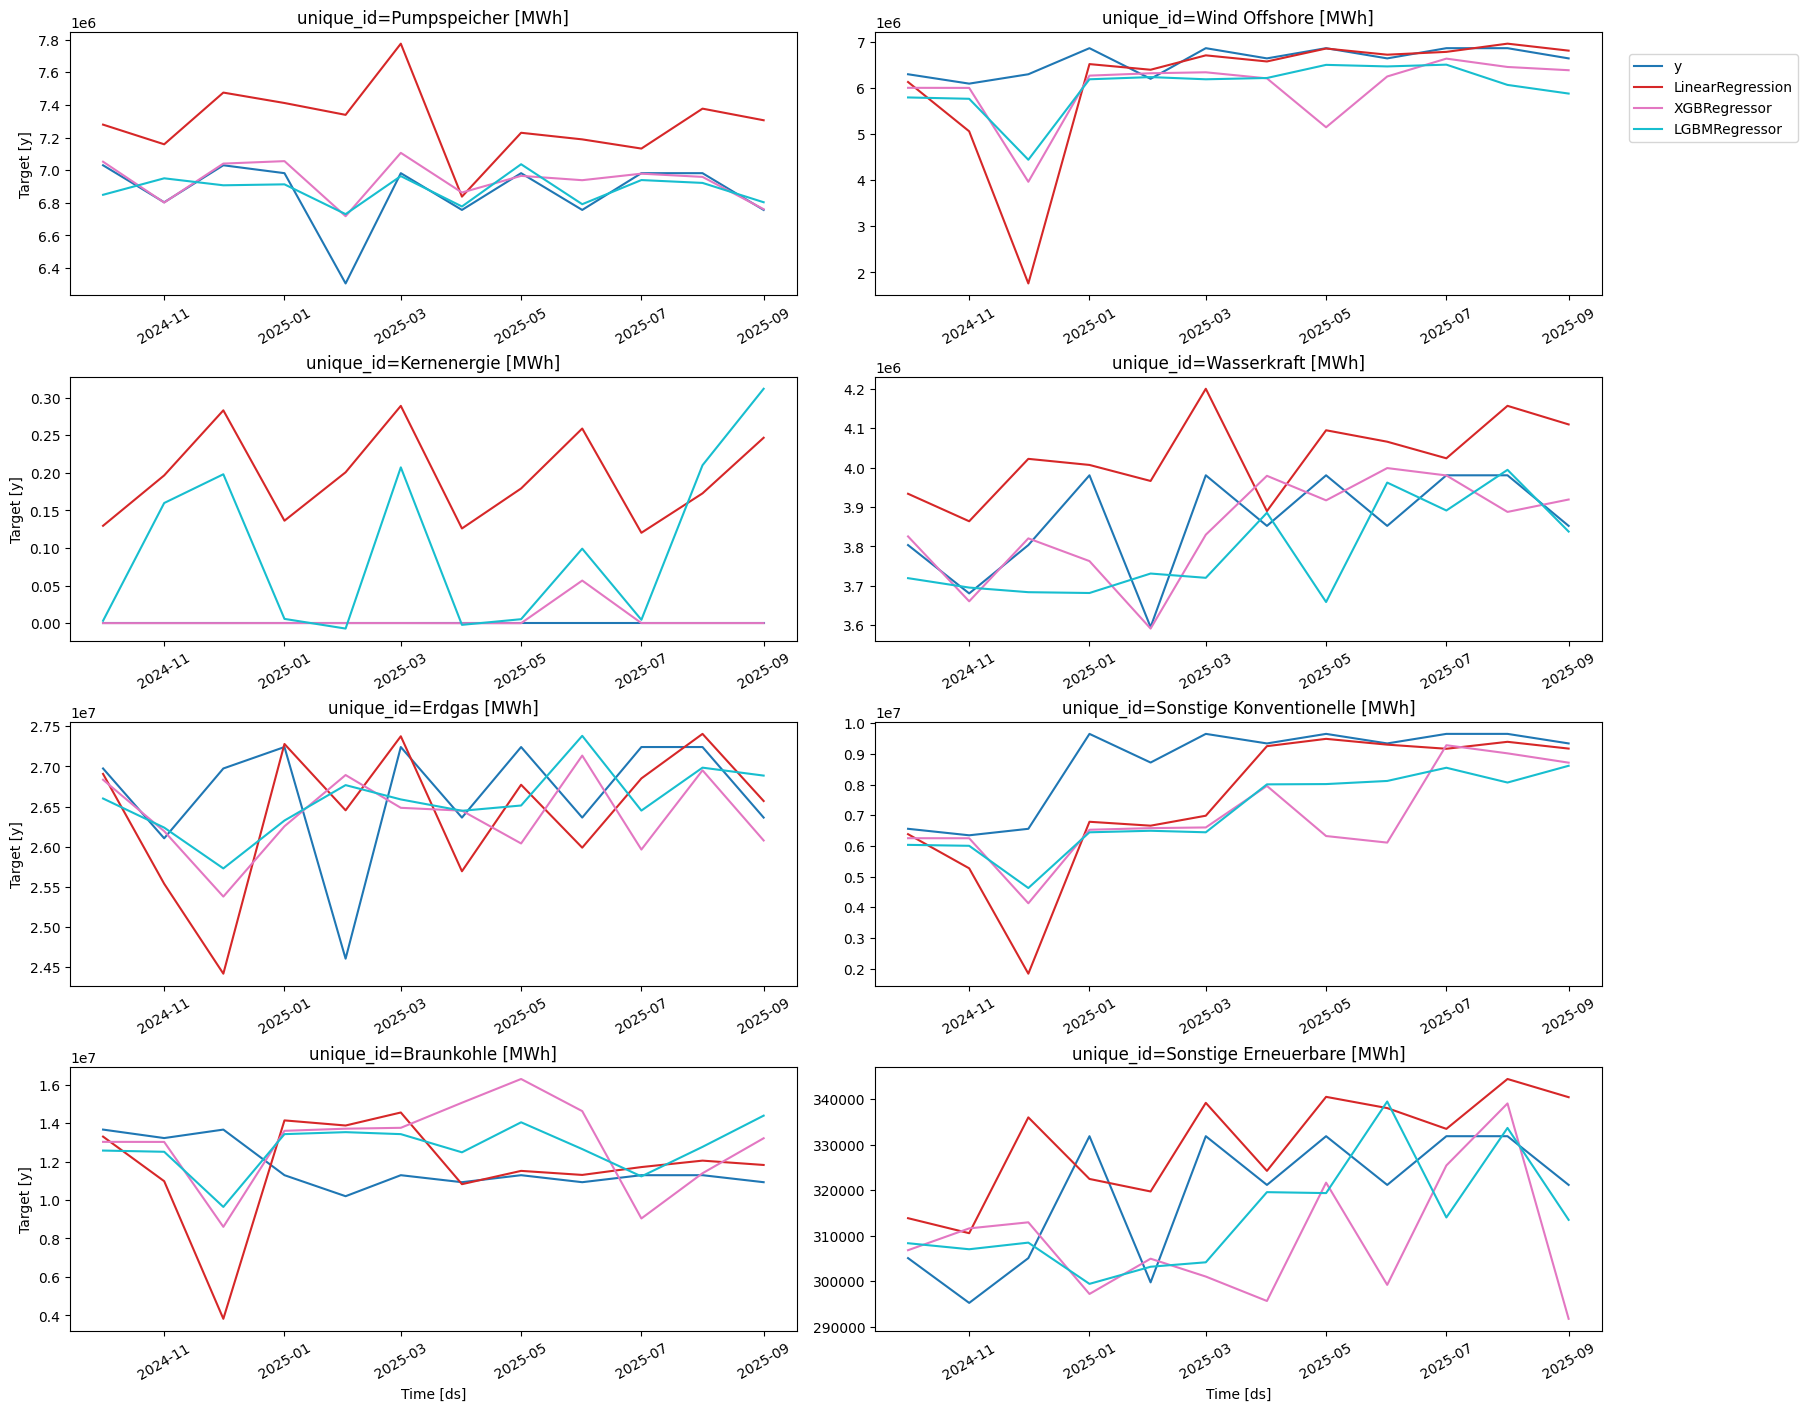

In [24]:
plot_series(forecasts_df=cv_ml.drop(columns='cutoff'))

In [25]:
mlf_cv_eval = evaluate(cv_ml.drop(columns="cutoff"), metrics=[mae])

mlf_cv_eval = mlf_cv_eval.drop(columns=["unique_id"]).groupby("metric").mean().reset_index()
mlf_cv_eval

,metric,LinearRegression,XGBRegressor,LGBMRegressor
0,mae,1.203836e+06,1.650264e+06,1.321481e+06


<Axes: >

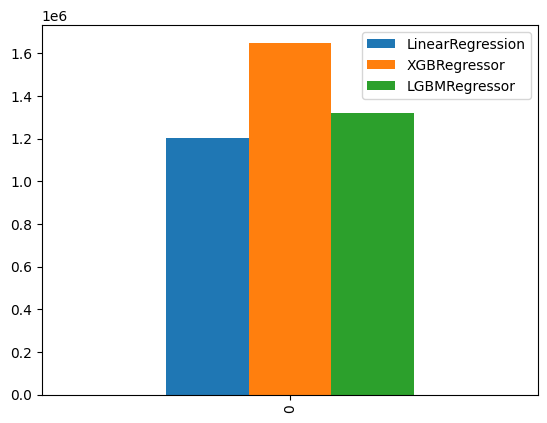

In [26]:
mlf_cv_eval.plot(kind="bar")

In [27]:
mlf_cv_eval = evaluate(cv_ml.drop(columns="cutoff"), metrics=[mae])
mlf_to_plot = mlf_cv_eval.drop(columns="metric").set_index("unique_id")
mlf_to_plot

,LinearRegression,XGBRegressor,LGBMRegressor
unique_id,,,
Biomasse [MWh],9.517269e+04,1.025520e+05,1.010655e+05
Braunkohle [MWh],2.084220e+06,2.636760e+06,2.037170e+06
Erdgas [MWh],6.237081e+05,8.139969e+05,7.404383e+05
Gesamtkapazität [MWh],5.855942e+06,8.864216e+06,6.760288e+06
Kernenergie [MWh],1.948792e-01,4.758216e-03,1.011631e-01
Photovoltaik [MWh],2.403014e+06,3.869826e+06,3.131113e+06
Pumpspeicher [MWh],4.301867e+05,8.164093e+04,1.017925e+05
Sonstige Erneuerbare [MWh],1.281265e+04,1.644668e+04,1.181576e+04
Sonstige Konventionelle [MWh],1.230294e+06,1.726369e+06,1.586921e+06


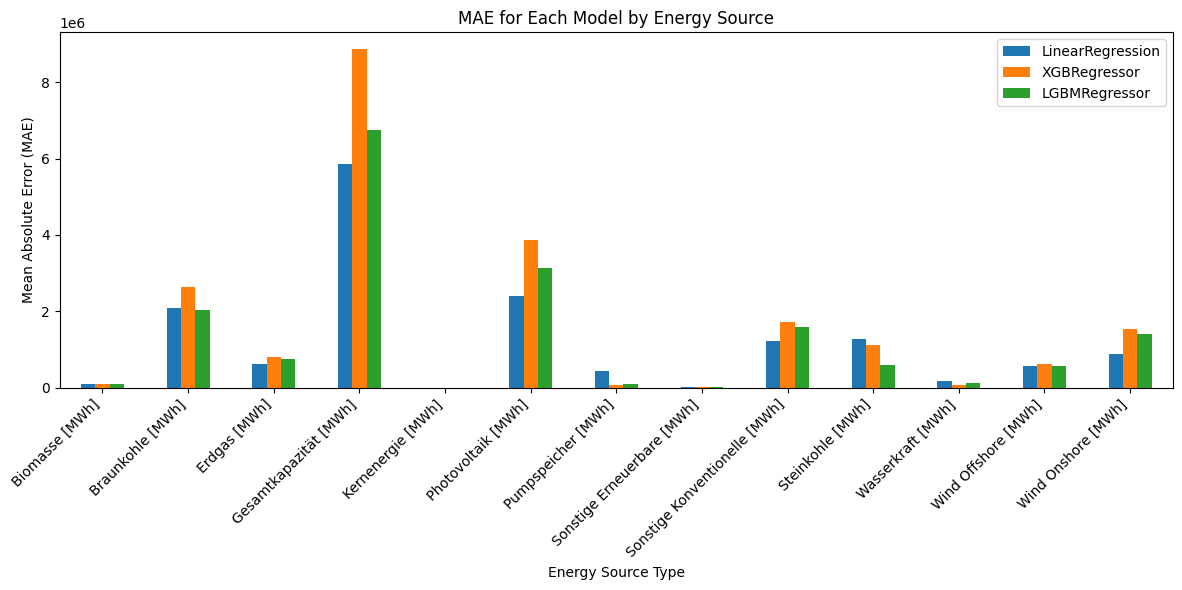

In [28]:
mlf_to_plot.plot(kind="bar", figsize=(12, 6))
plt.ylabel("Mean Absolute Error (MAE)")
plt.xlabel("Energy Source Type")
plt.title("MAE for Each Model by Energy Source")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

###NeuralForecast

In [29]:
models = [
    NHITS(h=3, input_size=12, n_pool_kernel_size=[4,2,1], n_freq_downsample=[12,4,1], scaler_type='robust', max_steps=1000, enable_progress_bar=False),
    TFT(h=3, input_size=12, hidden_size=128, scaler_type='robust', learning_rate=5e-4, max_steps=500, enable_progress_bar=False)
]

nf = NeuralForecast(models=models, freq='MS', local_scaler_type="standard")

nf.fit(trainCapacity)
predNNCap = nf.predict(h=3)

predNNCap.head()

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  2.4 M │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.4 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.4 M                                                                                                
Total estimated model params size (MB): 9                                                                          
Modules in train mode: 34                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                    ┃ Type                     ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss                    │ MAE                      │      0 │ train │     0 │
│ 1 │ padder_train            │ ConstantPad1d            │      0 │ train │     0 │
│ 2 │ scaler                  │ TemporalNorm             │      0 │ train │     0 │
│ 3 │ embedding               │ TFTEmbedding             │    512 │ train │     0 │
│ 4 │ temporal_encoder        │ TemporalCovariateEncoder │  613 K │ train │     0 │
│ 5 │ temporal_fusion_decoder │ TemporalFusionDecoder    │  256 K │ train │     0 │
│ 6 │ output_adapter          │ Linear                   │    129 │ train │     0 │
└───┴─────────────────────────┴──────────────────────────┴────────┴───────┴───────┘

Trainable params: 870 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 870 K                                                                                                
Total estimated model params size (MB): 3                                                                          
Modules in train mode: 88                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=500` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


,unique_id,ds,NHITS,TFT
0,Biomasse [MWh],2025-10-01,6521856.5,6437637.0
1,Biomasse [MWh],2025-11-01,6313121.5,6320504.0
2,Biomasse [MWh],2025-12-01,6522492.0,6425709.0
3,Braunkohle [MWh],2025-10-01,11307036.0,11347514.0
4,Braunkohle [MWh],2025-11-01,10868767.0,11226534.0


In [30]:
eval_df = pd.merge(testCapacity, predNNCap, how="left", on=["ds", "unique_id"])
evaluation = evaluate(eval_df, metrics=[mae])
evaluation.head()

,unique_id,metric,NHITS,TFT
0,Biomasse [MWh],mae,745.666667,63148.666667
1,Braunkohle [MWh],mae,57517.666667,146119.333333
2,Erdgas [MWh],mae,5534.666667,74825.333333
3,Gesamtkapazität [MWh],mae,35509.333333,428661.333333
4,Kernenergie [MWh],mae,0.000668,0.013130


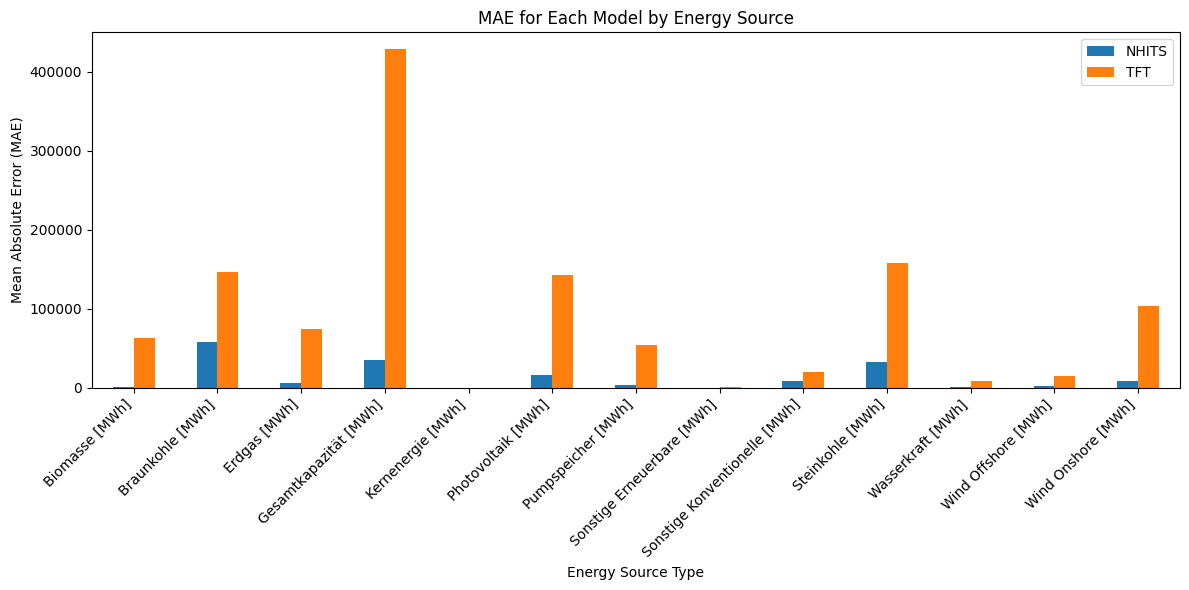

In [31]:
evaluation_to_plot = evaluation.drop(columns="metric").set_index("unique_id")

evaluation_to_plot.plot(kind="bar", figsize=(12, 6))
plt.ylabel("Mean Absolute Error (MAE)")
plt.xlabel("Energy Source Type")
plt.title("MAE for Each Model by Energy Source")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

NN Cross-Validation

In [32]:
models = [
    NHITS(h=3, input_size=12, n_pool_kernel_size=[4,2,1], n_freq_downsample=[12,4,1], scaler_type='robust', max_steps=1000, enable_progress_bar=False),
    TFT(h=3, input_size=12, hidden_size=128, scaler_type='robust', learning_rate=5e-4, max_steps=500, enable_progress_bar=False)
]

nf = NeuralForecast(models=models, freq='MS', local_scaler_type="standard")

cv_nf = nf.cross_validation(trainCapacity, n_windows=4, step_size=3)
cv_nf.head()

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  2.4 M │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.4 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.4 M                                                                                                
Total estimated model params size (MB): 9                                                                          
Modules in train mode: 34                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                    ┃ Type                     ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss                    │ MAE                      │      0 │ train │     0 │
│ 1 │ padder_train            │ ConstantPad1d            │      0 │ train │     0 │
│ 2 │ scaler                  │ TemporalNorm             │      0 │ train │     0 │
│ 3 │ embedding               │ TFTEmbedding             │    512 │ train │     0 │
│ 4 │ temporal_encoder        │ TemporalCovariateEncoder │  613 K │ train │     0 │
│ 5 │ temporal_fusion_decoder │ TemporalFusionDecoder    │  256 K │ train │     0 │
│ 6 │ output_adapter          │ Linear                   │    129 │ train │     0 │
└───┴─────────────────────────┴──────────────────────────┴────────┴───────┴───────┘

Trainable params: 870 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 870 K                                                                                                
Total estimated model params size (MB): 3                                                                          
Modules in train mode: 88                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=500` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


,unique_id,ds,cutoff,NHITS,TFT,y
0,Biomasse [MWh],2024-10-01,2024-09-01,6374705.5,6379957.0,6381288.0
1,Biomasse [MWh],2024-11-01,2024-09-01,6178507.5,6284302.0,6175440.0
2,Biomasse [MWh],2024-12-01,2024-09-01,6375104.0,6341545.0,6381288.0
3,Biomasse [MWh],2025-01-01,2024-12-01,6449202.0,6387255.0,6521904.0
4,Biomasse [MWh],2025-02-01,2024-12-01,6105653.5,6385935.5,5890752.0


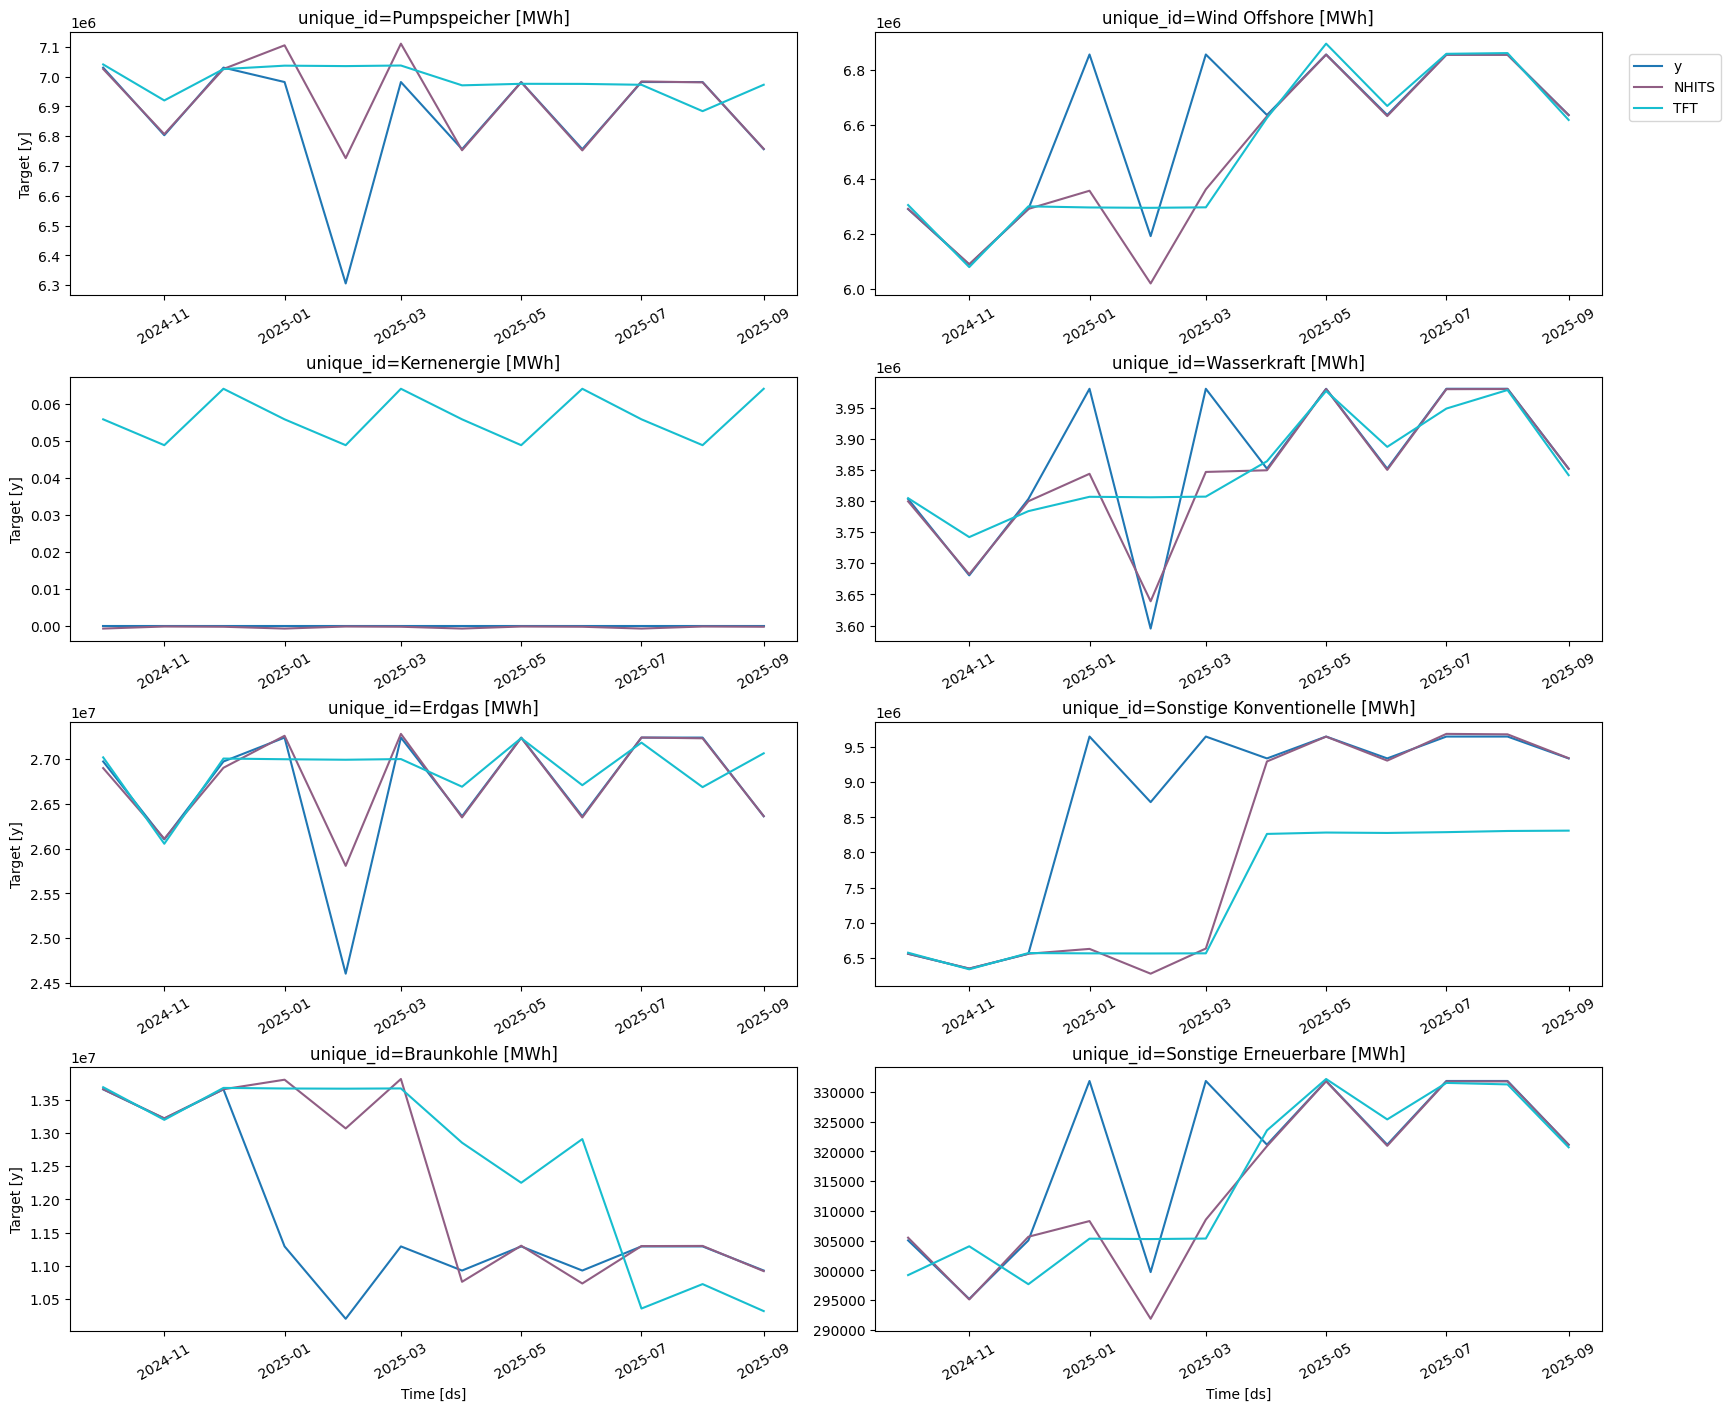

In [33]:
plot_series(forecasts_df=cv_nf.drop(columns='cutoff'))

<Axes: >

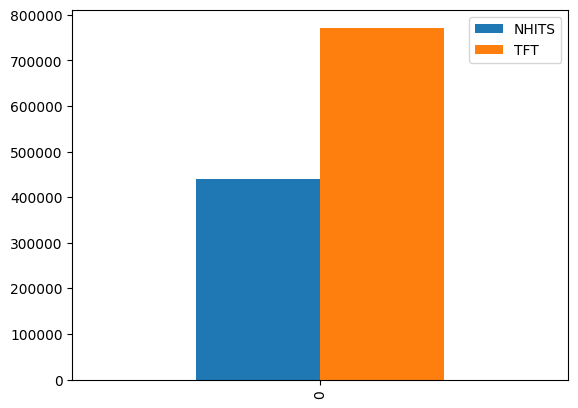

In [34]:
nf_cv_eval = evaluate(cv_nf.drop(columns="cutoff"), metrics=[mae])

nf_cv_eval = nf_cv_eval.drop(columns=["unique_id"]).groupby("metric").mean().reset_index()
nf_cv_eval.plot(kind="bar")

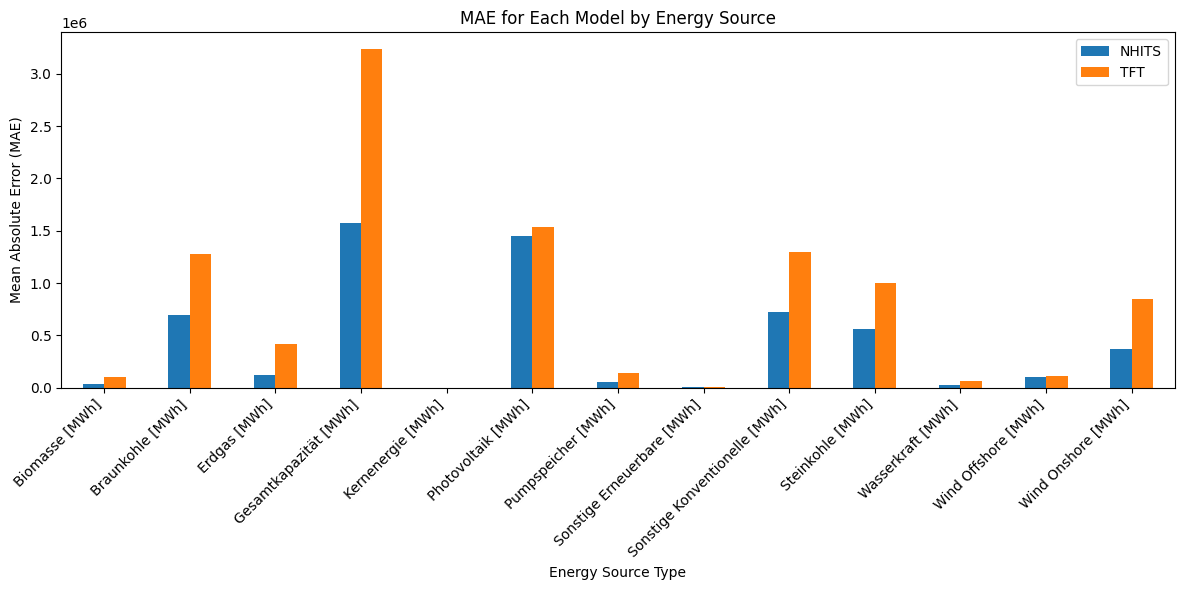

In [35]:
nf_cv_eval = evaluate(cv_nf.drop(columns="cutoff"), metrics=[mae])
nf_to_plot = nf_cv_eval.drop(columns="metric").set_index("unique_id")

nf_to_plot.plot(kind="bar", figsize=(12, 6))
plt.ylabel("Mean Absolute Error (MAE)")
plt.xlabel("Energy Source Type")
plt.title("MAE for Each Model by Energy Source")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##Combined Plots

MAE

In [36]:
nf_cv_eval_tc = nf_cv_eval.drop(columns="metric")
mlf_cv_eval_tc = mlf_cv_eval.drop(columns="metric")
cv_eval_tc = evaluate(cv.drop(columns="cutoff"), metrics=[mae]).drop(columns="metric")

In [37]:
combined_cv = pd.merge(cv_eval_tc, mlf_cv_eval_tc)
combined_cv = pd.merge(combined_cv, nf_cv_eval_tc)
combined_cv = combined_cv.set_index("unique_id")
combined_cv

,ARIMA,SARIMA,SeasonalNaive,LinearRegression,XGBRegressor,LGBMRegressor,NHITS,TFT
unique_id,,,,,,,,
Biomasse [MWh],1.437014e+05,3.651771e+04,119420.0,9.517269e+04,1.025520e+05,1.010655e+05,3.166629e+04,1.053400e+05
Braunkohle [MWh],8.786980e+05,8.786980e+05,5155620.0,2.084220e+06,2.636760e+06,2.037170e+06,6.934034e+05,1.275833e+06
Erdgas [MWh],6.310977e+05,1.396678e+06,1046564.0,6.237081e+05,8.139969e+05,7.404383e+05,1.213197e+05,4.161892e+05
Gesamtkapazität [MWh],4.334275e+06,9.285123e+06,16989554.0,5.855942e+06,8.864216e+06,6.760288e+06,1.571919e+06,3.235018e+06
Kernenergie [MWh],0.000000e+00,0.000000e+00,0.0,1.948792e-01,4.758216e-03,1.011631e-01,4.768060e-04,5.615851e-02
Photovoltaik [MWh],1.848057e+06,1.136302e+06,7691860.0,2.403014e+06,3.869826e+06,3.131113e+06,1.448990e+06,1.531996e+06
Pumpspeicher [MWh],1.812620e+05,1.812620e+05,67268.0,4.301867e+05,8.164093e+04,1.017925e+05,5.814346e+04,1.444952e+05
Sonstige Erneuerbare [MWh],1.011600e+04,1.011600e+04,24356.0,1.281265e+04,1.644668e+04,1.181576e+04,4.706247e+03,7.408146e+03
Sonstige Konventionelle [MWh],9.379388e+05,8.075078e+05,3874234.0,1.230294e+06,1.726369e+06,1.586921e+06,7.196938e+05,1.300201e+06


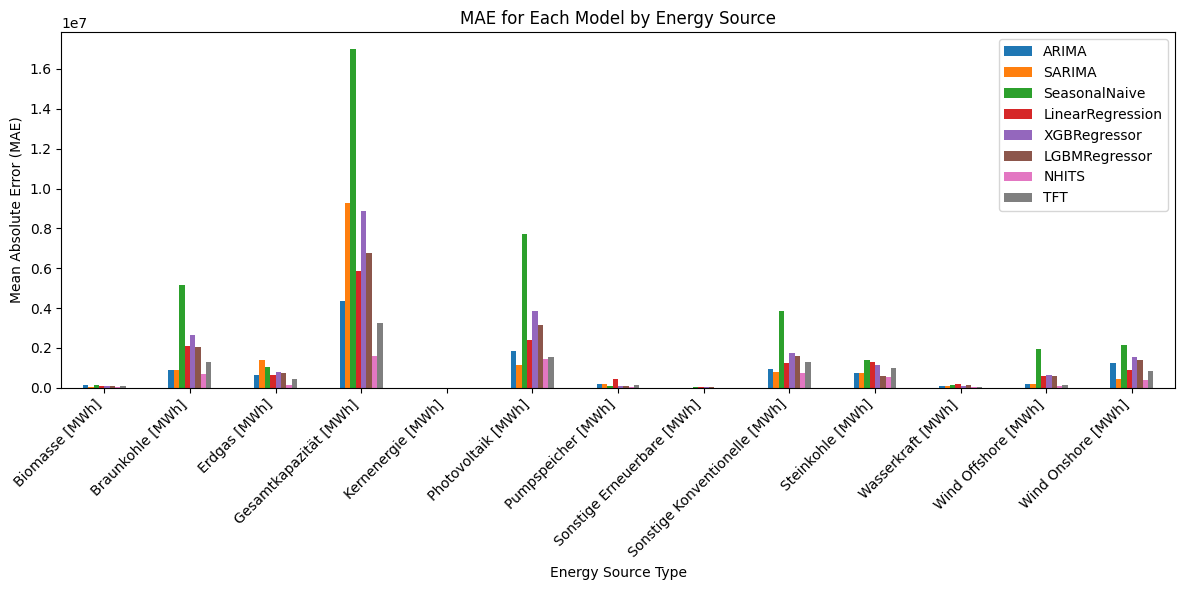

In [38]:
combined_cv.plot(kind="bar", figsize=(12, 6))
plt.ylabel("Mean Absolute Error (MAE)")
plt.xlabel("Energy Source Type")
plt.title("MAE for Each Model by Energy Source")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Combined Predictions

In [39]:
combinedPreds = pd.merge(testCapacity, predStatCap, "left", ["ds", "unique_id"])
combinedPreds = pd.merge(combinedPreds, predMlCap, "left", ["ds", "unique_id"])
combinedPreds = pd.merge(combinedPreds, predNNCap, "left", ["ds", "unique_id"])
combinedPreds.tail()

,ds,unique_id,y,ARIMA,SARIMA,SeasonalNaive,LinearRegression,XGBRegressor,LGBMRegressor,NHITS,TFT
34,2025-11-01,Pumpspeicher [MWh],6756480.0,6.756480e+06,6.756480e+06,6803280.0,6.828207e+06,6.865270e+06,6.680606e+06,6752136.5,6892237.5
35,2025-12-01,Pumpspeicher [MWh],6981696.0,6.756480e+06,6.756480e+06,7030056.0,6.893810e+06,6.665599e+06,6.925379e+06,6976910.0,6992650.0
36,2025-10-01,Sonstige Konventionelle [MWh],9650424.0,9.505890e+06,9.422347e+06,6556872.0,9.521759e+06,9.406367e+06,8.939728e+06,9661486.0,9675578.0
37,2025-11-01,Sonstige Konventionelle [MWh],9339120.0,9.672660e+06,9.339120e+06,6345360.0,9.668510e+06,9.361985e+06,8.939728e+06,9335404.0,9359814.0
38,2025-12-01,Sonstige Konventionelle [MWh],9650424.0,9.839430e+06,9.422347e+06,6556872.0,8.993689e+06,8.630982e+06,8.106452e+06,9661896.0,9665750.0


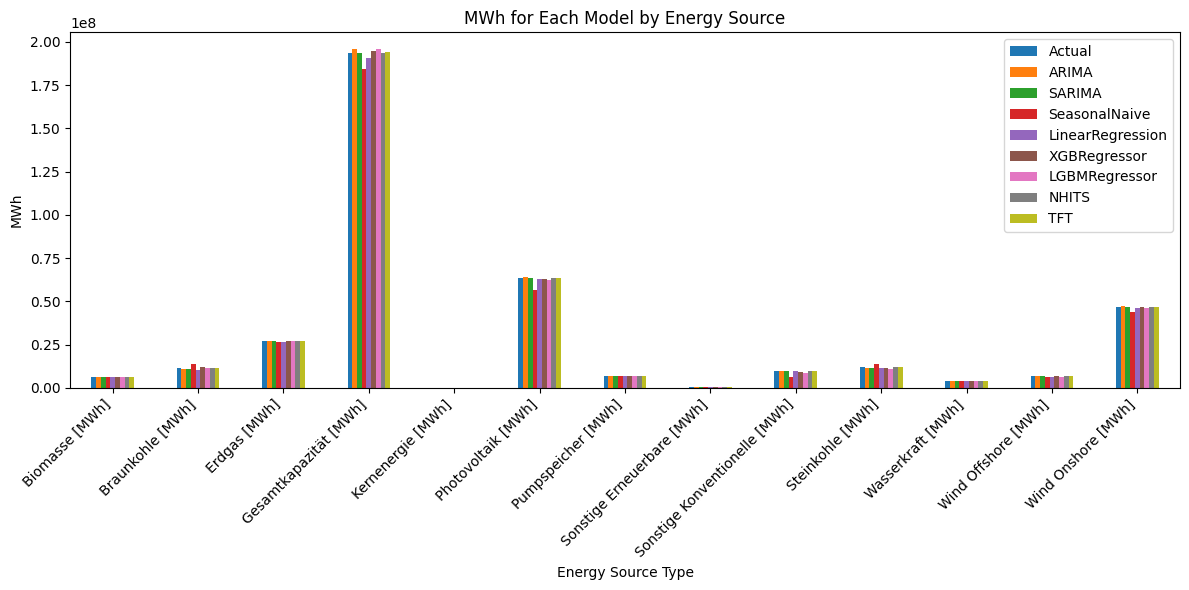

In [40]:
combPredsExGesamt = combinedPreds.loc[combinedPreds["unique_id"] != "Gesamterzeugung [MWh]"]
combPredsExGesamt = combPredsExGesamt.drop(columns="ds")
combPredsExGesamt = combPredsExGesamt.set_index("unique_id")
combPredsExGesamt = combPredsExGesamt.rename(columns={"y": "Actual"})

combPredsExGesamt.groupby(combPredsExGesamt.index).mean().plot(kind="bar", figsize=(12, 6))
plt.ylabel("MWh")
plt.xlabel("Energy Source Type")
plt.title("MWh for Each Model by Energy Source")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

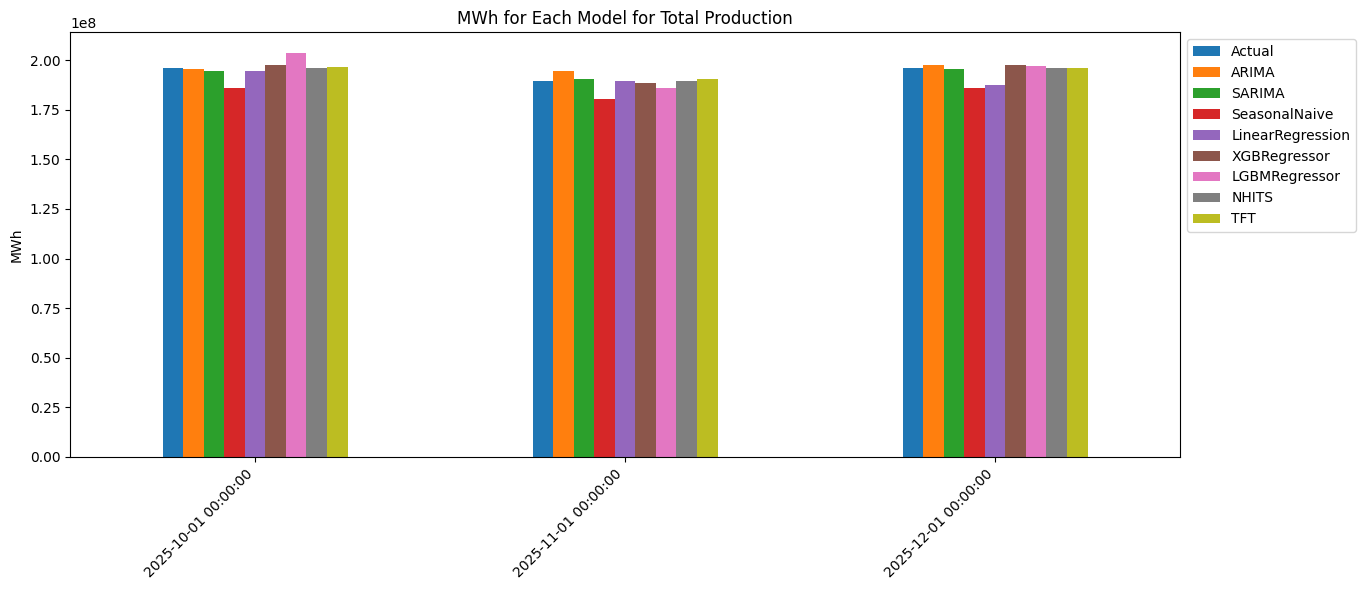

In [41]:
combPredsGesamt = combinedPreds.loc[combinedPreds["unique_id"] == "Gesamtkapazität [MWh]"]
combPredsGesamt = combPredsGesamt.drop(columns="unique_id")
combPredsGesamt = combPredsGesamt.set_index("ds")
combPredsGesamt = combPredsGesamt.rename(columns={"y": "Actual"})

combPredsGesamt.groupby(combPredsGesamt.index).mean().plot(kind="bar", figsize=(12, 6))
plt.ylabel("MWh")
plt.xlabel("")
plt.title("MWh for Each Model for Total Production")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.show()

###Forecast Plot with Best ML Model

In [42]:
statmodels = ["ARIMA", "SARIMA", "SeasonalNaive"]
bestForecastModel = combined_cv.loc["Gesamtkapazität [MWh]"].drop(labels=statmodels, axis=0).idxmin()
bestForecastModel

'NHITS'

In [43]:
forecast = combinedPreds.loc[combinedPreds["unique_id"] == "Gesamtkapazität [MWh]", ["ds", bestForecastModel]]
forecast = forecast.set_index("ds")
forecast

,NHITS
ds,
2025-10-01,195992288.0
2025-11-01,189735808.0
2025-12-01,195984256.0


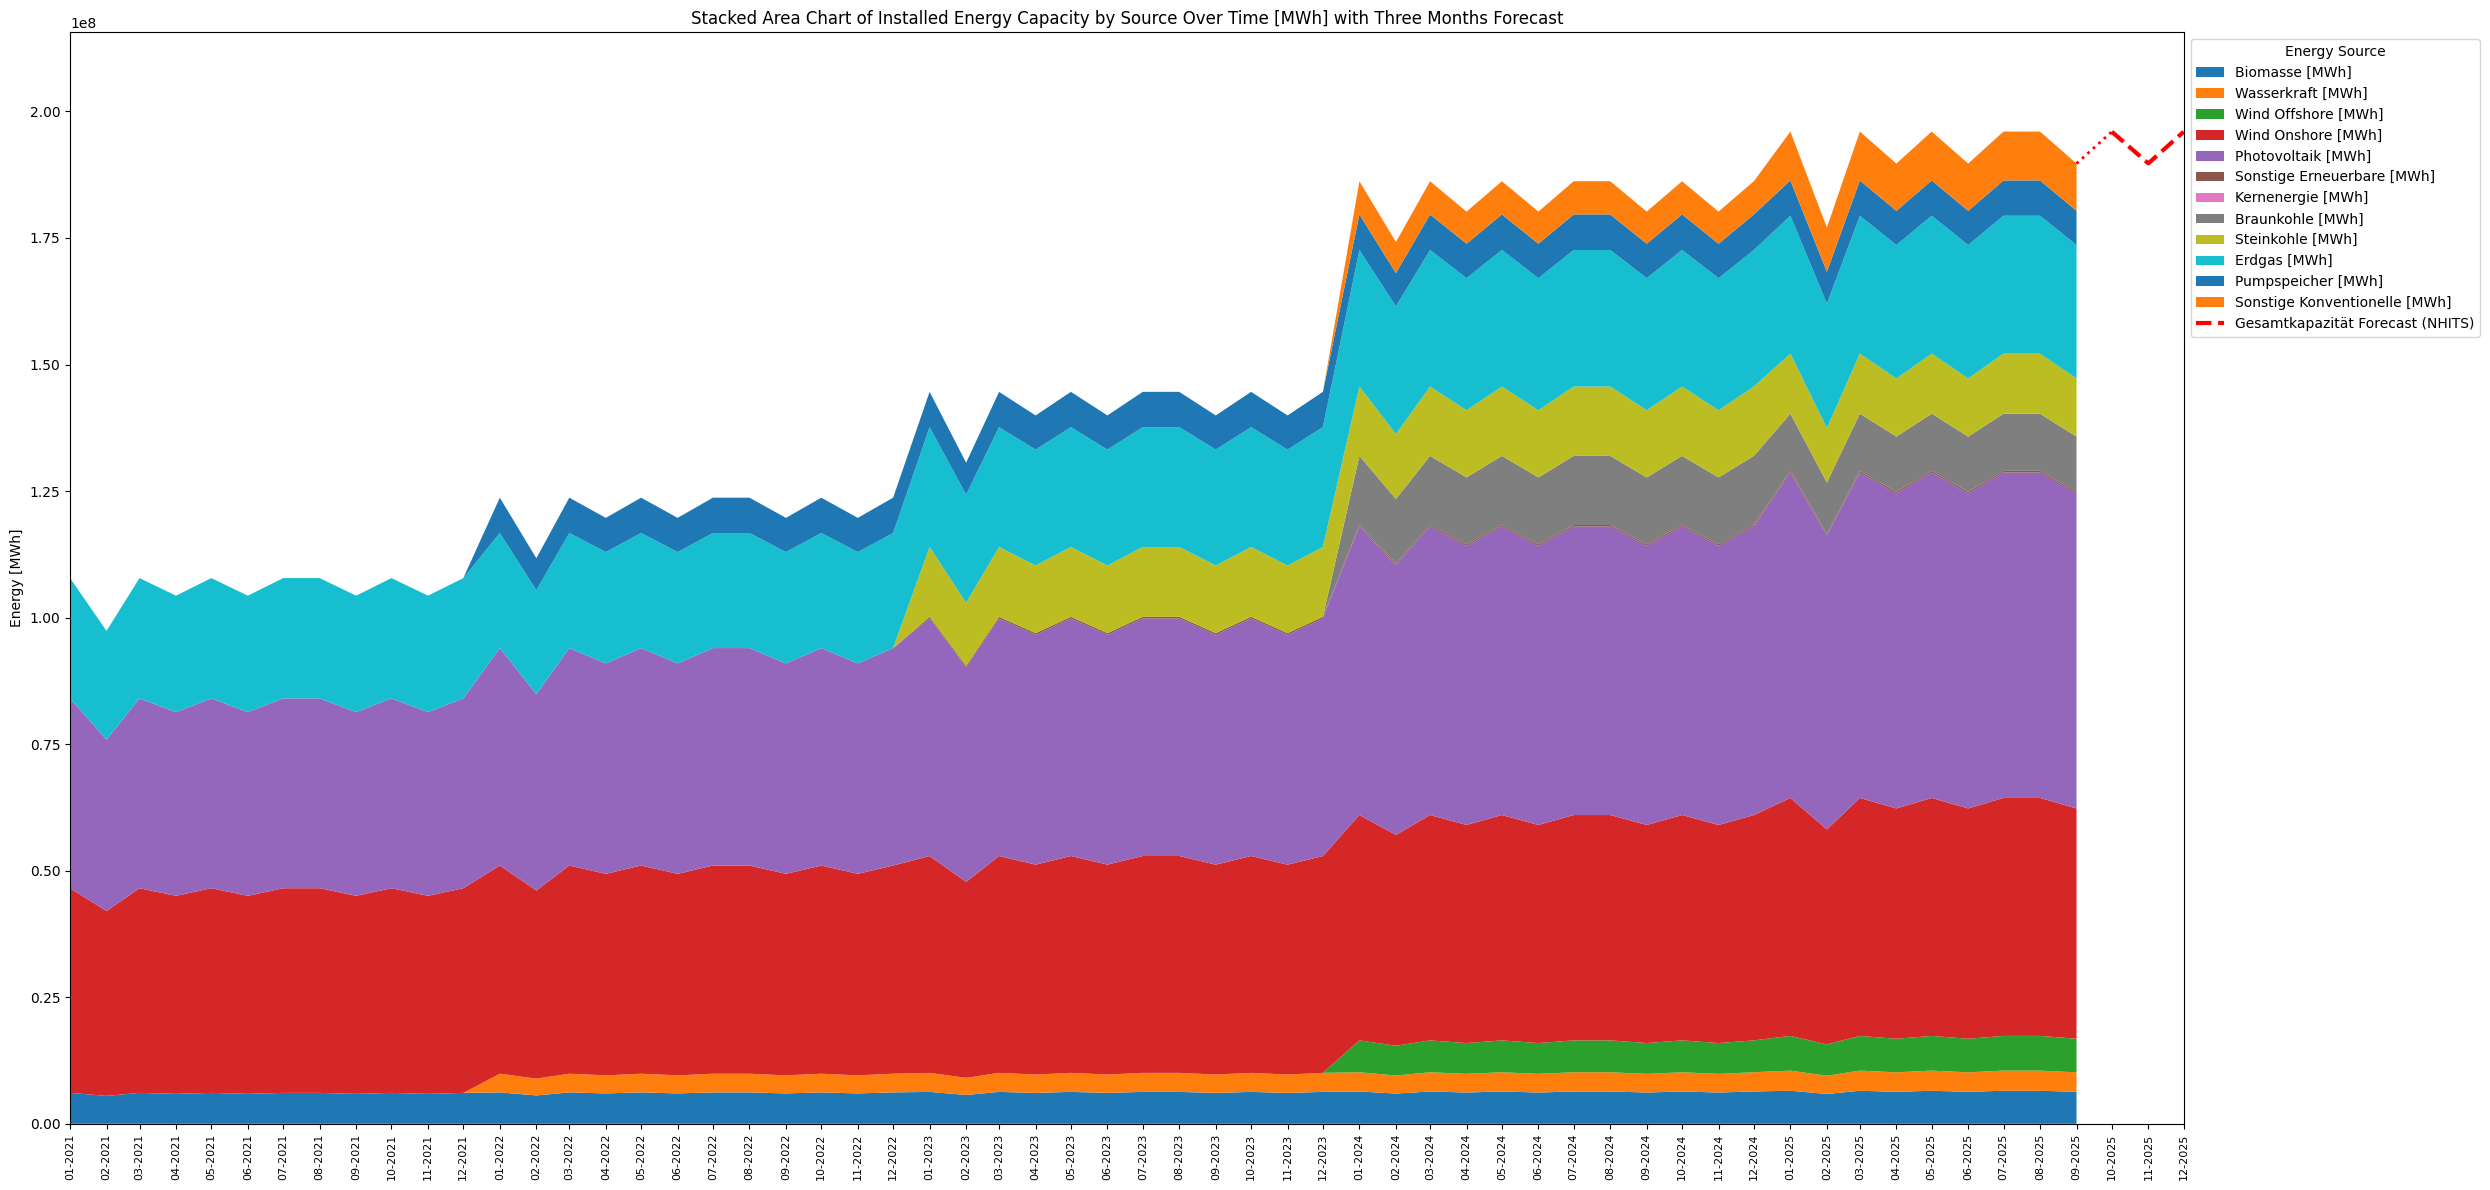

In [44]:
capacityPlotDf = capacity.iloc[:-3].set_index("Datum von").drop(columns=["Datum bis", "Gesamtkapazität [MWh]"])

productionDates = capacityPlotDf.index
forecastDates = forecast.index
allDates = productionDates.append(forecastDates)
allLabels = allDates.strftime("%m-%Y")

fig, ax = plt.subplots(figsize=(25, 12))

ax.stackplot(capacityPlotDf.index, capacityPlotDf.values.T, labels=capacityPlotDf.columns)
ax.plot(forecast.index, forecast[bestForecastModel], color='red', linestyle="--", linewidth=3, label=f'Gesamtkapazität Forecast ({bestForecastModel})')

last_historical_total = capacityPlotDf.sum(axis=1).iloc[-1]
first_forecast_value = forecast[bestForecastModel].iloc[0]

bridge_x = [productionDates.max(), forecastDates.min()]
bridge_y = [last_historical_total, first_forecast_value]
ax.plot(bridge_x, bridge_y, color='red', linestyle=':', linewidth=2)

max_historical_sum = capacityPlotDf.sum(axis=1).max()
max_forecast_value = forecast[f'{bestForecastModel}'].max()
max_y_value = max(max_historical_sum, max_forecast_value)
ax.set_ylim(bottom=0, top=max_y_value * 1.1)

ax.set_xlim(allDates.min(), allDates.max())
ax.set_xticks(allDates)
ax.set_xticklabels(allLabels, rotation=90, ha='center', fontsize=8)

ax.set_title('Stacked Area Chart of Installed Energy Capacity by Source Over Time [MWh] with Three Months Forecast')
ax.set_ylabel('Energy [MWh]')
ax.set_xlabel('')
ax.legend(title='Energy Source', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()